# Exercício 2 B — Pipeline de percepção com OpenCV DNN

**Origem da cena:** imagem `FudanPed00046.png` do Penn-Fudan (pedestres). O pipeline executa em ordem `undistort → HSV → ORB → HOG+SVM → OpenCV DNN`. O bloco final informa latência individual em milissegundos e exibe a imagem anotada.

**Limitação geométrica:** os únicos coeficientes disponíveis em `resultados/ex1/calibracao.npz` foram estimados de outra câmera (vídeo público de tabuleiro), não da câmera com a qual Penn-Fudan foi capturado. A chamada `cv2.undistort` é demonstrativa e não valida correção geométrica para esta cena. Para uma validação física, calibrem a webcam/ câmera de origem da cena e gravem novos parâmetros no Exercício 1.

O detector HOG é o detector linear SVM de pessoas distribuído com OpenCV. O classificador ImageNet pode atribuir rótulos genéricos a um recorte de pessoa, pois ele não foi treinado para a tarefa “é pedestre” e não recebe ground truth ImageNet para este recorte.

In [1]:
from pathlib import Path
import json, time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if ROOT.name != "ATRETORNO":
    ROOT = ROOT / "ATRETORNO" if (ROOT / "ATRETORNO").is_dir() else ROOT
DATA = ROOT / "dados"
MODELS = ROOT / "modelos"
OUT = ROOT / "resultados" / "ex2"
OUT.mkdir(parents=True, exist_ok=True)
cv2.setNumThreads(4)

def read_image_unicode(path):
    image = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return image

def save_image_unicode(path, image):
    ok, encoded = cv2.imencode(Path(path).suffix or ".jpg", image)
    if not ok:
        raise RuntimeError(f"Falha ao codificar {path}")
    encoded.tofile(path)

print(f"OpenCV {cv2.__version__}; frame BGR, uint8")

OpenCV 4.11.0; frame BGR, uint8


In [2]:
# 1. Carrega a cena de pedestres e corrige a distorção com os parâmetros do Ex.1.
source = DATA / "PennFudanPed" / "PNGImages" / "FudanPed00046.png"
t0 = time.perf_counter()
frame = read_image_unicode(source)  # Aquisição sequencial: um frame já gravado no dataset.
tempo_captura = (time.perf_counter() - t0) * 1000
cal = np.load(ROOT / "resultados" / "ex1" / "calibracao.npz")
K_source, dist = cal["K"], cal["dist"]
cal_w, cal_h = map(int, cal["tamanho"])
h, w = frame.shape[:2]
K = K_source.copy()
K[0, :] *= w / cal_w
K[1, :] *= h / cal_h
t0 = time.perf_counter()
undistorted = cv2.undistort(frame, K, dist)
tempo_undistort = (time.perf_counter() - t0) * 1000
annotated = undistorted.copy()
tempos = {"captura (arquivo)": tempo_captura, "undistort": tempo_undistort}
print(f"Aquisição do frame (arquivo): {tempo_captura:.2f} ms | undistort: {tempo_undistort:.2f} ms | entrada={w}x{h}")

Aquisição do frame (arquivo): 5.79 ms | undistort: 3.73 ms | entrada=567x438


In [3]:
# 2. Segmenta uma ROI pelo matiz/saturação HSV. Saturação alta reduz fundo neutro;
# trata-se de uma máscara exploratória, não de uma classe semântica pedestre.
t0 = time.perf_counter()
hsv = cv2.cvtColor(undistorted, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv, np.array([0, 45, 30], np.uint8), np.array([179, 255, 255], np.uint8))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3),np.uint8))
tempo_hsv = (time.perf_counter() - t0) * 1000
tempos["HSV"] = tempo_hsv
overlay = annotated.copy()
overlay[mask > 0] = (0, 180, 255)
annotated = cv2.addWeighted(annotated, .82, overlay, .18, 0)
print(f"Etapa 2 — HSV: {tempo_hsv:.2f} ms | pixels segmentados={np.count_nonzero(mask)} ({100*np.mean(mask>0):.1f}%)")

Etapa 2 — HSV: 1.13 ms | pixels segmentados=41059 (16.5%)


In [4]:
# 3. Extrai pontos ORB do frame. Os pontos amarelos mostram a representação local.
t0 = time.perf_counter()
gray = cv2.cvtColor(undistorted, cv2.COLOR_BGR2GRAY)
orb = cv2.ORB_create(nfeatures=500)
orb.detectAndCompute(gray, None)  # Aquecimento excluído da medição.
t0 = time.perf_counter()
keypoints, descriptors = orb.detectAndCompute(gray, None)
tempo_orb = (time.perf_counter() - t0) * 1000
tempos["ORB"] = tempo_orb
for kp in keypoints[:100]:
    cv2.circle(annotated, tuple(np.rint(kp.pt).astype(int)), 2, (0, 255, 255), -1)
print(f"Etapa 3 — ORB: {tempo_orb:.2f} ms | pontos={len(keypoints)} | descritores={None if descriptors is None else descriptors.shape}")

Etapa 3 — ORB: 5.92 ms | pontos=500 | descritores=(500, 32)


In [5]:
# 4. detectMultiScale usa HOG + SVM linear padrão do OpenCV.
t0 = time.perf_counter()
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
hog.detectMultiScale(undistorted, winStride=(8,8), padding=(8,8), scale=1.05)  # Aquecimento.
t0 = time.perf_counter()
boxes, weights = hog.detectMultiScale(undistorted, winStride=(8,8), padding=(8,8), scale=1.05)
tempo_hog = (time.perf_counter() - t0) * 1000
tempos["HOG + SVM"] = tempo_hog
if len(boxes) == 0:
    raise RuntimeError("HOG não encontrou pessoa nesta imagem; escolha outro frame Penn-Fudan.")
# Seleciona o maior score, registra as demais detecções no frame.
idx = int(np.argmax(weights.ravel()))
x,y,bw,bh = map(int, boxes[idx])
for (bx,by,bw0,bh0), score in zip(boxes, weights.ravel()):
    cv2.rectangle(annotated, (int(bx),int(by)), (int(bx+bw0),int(by+bh0)), (0,255,0), 2)
    cv2.putText(annotated, f"HOG {float(score):.2f}", (int(bx),max(18,int(by)-4)), cv2.FONT_HERSHEY_SIMPLEX,.45,(0,255,0),1)
roi = undistorted[y:y+bh, x:x+bw]
if roi.size == 0:
    raise RuntimeError("ROI HOG vazia.")
roi_mask = mask[y:y+bh, x:x+bw]
roi_foreground = float(np.mean(roi_mask > 0))
print(f"Etapa 4 — HOG + SVM: {tempo_hog:.2f} ms | detecções={len(boxes)} | ROI={(x,y,bw,bh)}")
print(f"Pixels HSV segmentados dentro da ROI escolhida: {100*roi_foreground:.1f}%")

Etapa 4 — HOG + SVM: 64.59 ms | detecções=4 | ROI=(435, 63, 132, 294)
Pixels HSV segmentados dentro da ROI escolhida: 29.8%


In [6]:
# 5. Classifica a ROI com o ONNX dos mesmos pesos da MobileNetV2 do item A.
# blobFromImage cria tensor NCHW RGB [-1,1], compatível com a exportação do Keras.
net = cv2.dnn.readNetFromONNX(np.fromfile(MODELS / "mobilenetv2.onnx", np.uint8))
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
blob = cv2.dnn.blobFromImage(roi, 1/127.5, (224,224), (127.5,127.5,127.5), swapRB=True, crop=False)
net.setInput(blob)
net.forward()  # Aquecimento; a leitura do grafo também fica fora da latência.
net.setInput(blob)
t0 = time.perf_counter()
scores = net.forward().ravel()
tempo_dnn = (time.perf_counter() - t0) * 1000
tempos["DNN ROI"] = tempo_dnn
classes = json.loads((MODELS / "classes.json").read_text(encoding="utf-8"))
top3 = np.argsort(scores)[-3:][::-1]
for i, class_id in enumerate(top3):
    label = classes[str(int(class_id))][1]
    confidence = float(scores[class_id])
    cv2.putText(annotated, f"{label}: {confidence:.1%}", (8,25+23*i), cv2.FONT_HERSHEY_SIMPLEX,.52,(255,255,255),1,cv2.LINE_AA)
    print(f"Top-{i+1}: {label} ({confidence:.2%})")
cv2.rectangle(annotated,(x,y),(x+bw,y+bh),(255,0,255),3)
print(f"Etapa 5 — OpenCV DNN: {tempo_dnn:.2f} ms | classifica ROI HOG")

Top-1: abaya (9.49%)
Top-2: unicycle (6.15%)
Top-3: trench_coat (5.24%)
Etapa 5 — OpenCV DNN: 16.69 ms | classifica ROI HOG



Tempo por etapa (ms):
  captura (arquivo) 5.79
  undistort    3.73
  HSV          1.13
  ORB          5.92
  HOG + SVM    64.59
  DNN ROI      16.69
  TOTAL        97.86

Frame anotado: D:\Faculdade\Visão Computacional para Robótica\ATRETORNO\resultados\ex2\pipeline_final.jpg


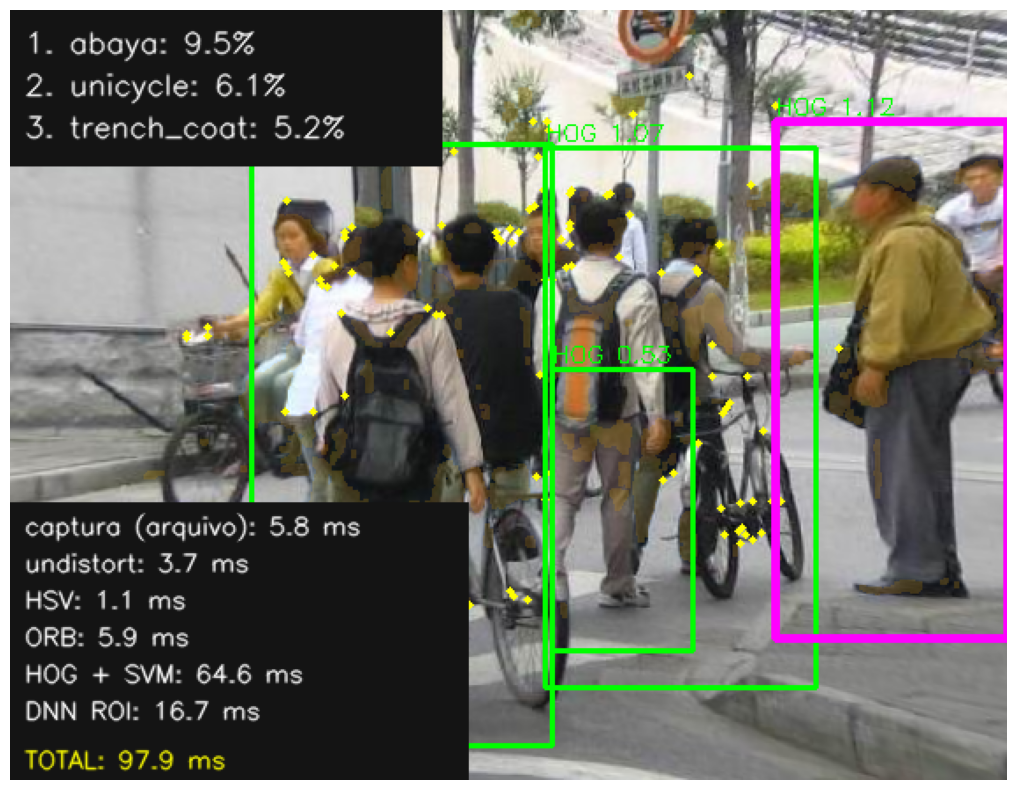

In [7]:
# Resumo auditável e artefatos pedidos.
cv2.rectangle(annotated,(0,0),(245,88),(20,20,20),-1)
for i,(class_id) in enumerate(top3):
    label = classes[str(int(class_id))][1]
    cv2.putText(annotated, f"{i+1}. {label}: {scores[class_id]:.1%}", (8,24+24*i), cv2.FONT_HERSHEY_SIMPLEX,.55,(255,255,255),1,cv2.LINE_AA)
cv2.rectangle(annotated,(0,h-158),(260,h),(20,20,20),-1)
for i,(stage,ms) in enumerate(tempos.items()):
    cv2.putText(annotated, f"{stage}: {ms:.1f} ms", (8,h-140+21*i), cv2.FONT_HERSHEY_SIMPLEX,.46,(255,255,255),1,cv2.LINE_AA)
cv2.putText(annotated, f"TOTAL: {sum(tempos.values()):.1f} ms", (8,h-7), cv2.FONT_HERSHEY_SIMPLEX,.46,(0,255,255),1,cv2.LINE_AA)
save_image_unicode(OUT / "pipeline_final.jpg", annotated)
save_image_unicode(OUT / "pipeline_hsv_mask.png", mask)
summary = {"imagem": str(source.relative_to(ROOT)), "origem_imagem":"Penn-Fudan, FudanPed00046.png",
           "calibracao":str((ROOT / "resultados" / "ex1" / "calibracao.npz").relative_to(ROOT)),
           "calibracao_camera_correspondente":False,
           "alerta":"Demonstração funcional: calibração de câmera pública distinta da imagem Penn-Fudan; não interpretar como undistort metrologicamente válido.",
           "deteccoes_hog":len(boxes),"keypoints_orb":len(keypoints),"top3":[{"classe":classes[str(int(i))][1],"confianca":float(scores[i])} for i in top3],
           "tempos_ms":tempos,"tempo_total_ms":float(sum(tempos.values()))}
(OUT / "pipeline_metricas.json").write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding="utf-8")
print("\nTempo por etapa (ms):")
for stage,ms in tempos.items(): print(f"  {stage:12s} {ms:.2f}")
print(f"  {'TOTAL':12s} {sum(tempos.values()):.2f}")
print("\nFrame anotado:", OUT / "pipeline_final.jpg")
plt.figure(figsize=(12,8)); plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.tight_layout(); plt.show()